In [1]:
import os
import shutil
import json
import re

In [2]:
def get_models(root_folder):
    valid_subfolders = []
    for subfolder_name in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder_name)
        if os.path.isdir(subfolder_path):
            output_folder_path = os.path.join(subfolder_path, 'output')
            if os.path.isdir(output_folder_path) and os.listdir(output_folder_path):
                valid_subfolders.append(subfolder_name)
    return valid_subfolders

In [3]:
models = get_models('model_output')
model_name = models[1]
models

['Llama-3-70B-Instruct_3_shot',
 'Llama-3-8B-Instruct-Gradient-1048k_5_shot',
 'OpenBioLLM-Llama3-70B_3_shot']

In [4]:
label_folder = "../../input/lct_p3"
model_folder = f"model_output/{model_name}/output"
ready_folder = f"model_output/{model_name}/ready"
failure_folder = f"model_output/{model_name}/failure"

categories = ['Condition', 'Observation', 'Drug']

#### Filter failure model files

In [5]:
def read_and_process_files(model_name):
    model_folder = f"model_output/{model_name}/output"
    ready_folder = f"model_output/{model_name}/ready"
    failure_folder = f"model_output/{model_name}/failure"
    os.makedirs(ready_folder, exist_ok=True)
    os.makedirs(failure_folder, exist_ok=True)

    def visit(node, category, entities):
        if isinstance(node, dict):
            if category in node:
                entities.extend(node[category])
            for value in node.values():
                visit(value, category, entities)
        elif isinstance(node, list):
            for item in node:
                visit(item, category, entities)

    for filename in os.listdir(model_folder):
        if filename.endswith(".json"):
            file_path = os.path.join(model_folder, filename)
            try:
                with open(file_path, 'r', encoding="utf-8") as file:
                    data = json.load(file)
                entities = []
                visit(data, 'category', entities)
                shutil.copy(file_path, ready_folder)
            except Exception as e:
                shutil.copy(file_path, failure_folder)
                print(f"Error processing file {filename}: {e}")

read_and_process_files(model_name)

Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860025_exc_5_shot.json: Expecting ',' delimiter: line 83 column 2 (char 2200)
Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860064_inc_5_shot.json: Expecting ',' delimiter: line 54 column 2 (char 1601)
Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860116_inc_5_shot.json: Expecting ',' delimiter: line 45 column 2 (char 1282)
Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860233_exc_5_shot.json: Expecting ',' delimiter: line 38 column 23 (char 1560)
Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860259_exc_5_shot.json: Expecting ',' delimiter: line 23 column 23 (char 801)
Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860337_inc_5_shot.json: Expecting ',' delimiter: line 34 column 2 (char 1095)
Error processing file Llama-3-8B-Instruct-Gradient-1048k_NCT03860350_exc_5_shot.json: Expecting ',' delimiter: line 15 column 27 (char 373)
Error processing fi

In [12]:
def visit(node, category, entities):
    if isinstance(node, dict):
        if category in node:
            entities.extend(node[category])
        for value in node.values():
            visit(value, category, entities)
    elif isinstance(node, list):
        for item in node:
            visit(item, category, entities)

def calculate_metrics(label_data, model_data, metrics):
    for category in categories:
        label_entities = []
        visit(label_data, category, label_entities)
        model_entities = []
        visit(model_data, category, model_entities)

        true_positives = sum(entity in label_entities for entity in model_entities)
        false_positives = sum(entity not in label_entities for entity in model_entities)
        false_negatives = sum(entity not in model_entities for entity in label_entities)

        metrics[category]['true_positives'] += true_positives
        metrics[category]['false_positives'] += false_positives
        metrics[category]['false_negatives'] += false_negatives

        # Count total entities in labels and model outputs
        metrics[category]['total_label_entities'] += len(label_entities)
        metrics[category]['total_model_entities'] += len(model_entities)

def process_files(label_folder, model_folder):
    metrics = {category: {'true_positives': 0, 'false_positives': 0, 'false_negatives': 0,
                          'total_label_entities': 0, 'total_model_entities': 0} for category in categories}
    for filename in os.listdir(model_folder):
        if filename.endswith('.json'):
            model_path = os.path.join(model_folder, filename)
            match = re.search(r'NCT\d+_(?:exc|inc)', filename)
            if match:
                label_filename = f"{match.group(0)}_p3.json"
                label_path = os.path.join(label_folder, label_filename)

                if os.path.exists(label_path):
                    try:
                        with open(label_path, 'r', encoding='utf-8') as label_file, open(model_path, 'r', encoding='utf-8') as model_file:
                            label_data = json.load(label_file)
                            model_data = json.load(model_file)
                            calculate_metrics(label_data, model_data, metrics)
                    except json.JSONDecodeError as e:
                        print(f"Error decoding JSON file: {model_path}")
                        print(f"Error message: {str(e)}")

    for category in categories:
        true_positives = metrics[category]['true_positives']
        false_positives = metrics[category]['false_positives']
        false_negatives = metrics[category]['false_negatives']

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = true_positives / (true_positives + false_positives + false_negatives) if (true_positives + false_positives + false_negatives) > 0 else 0

        metrics[category]['precision'] = precision
        metrics[category]['recall'] = recall
        metrics[category]['f1'] = f1
        metrics[category]['accuracy'] = accuracy

    return metrics


In [13]:
metrics = process_files(label_folder, ready_folder)

print("Metrics:")
for category, scores in metrics.items():
    print(f"{category}:")
    print(f"  Precision: {scores['precision']:.4f}")
    print(f"  Recall: {scores['recall']:.4f}")
    print(f"  F1-score: {scores['f1']:.4f}")
    print(f"  Accuracy: {scores['accuracy']:.4f}")

Metrics:
Condition:
  Precision: 0.2501
  Recall: 0.4047
  F1-score: 0.3091
  Accuracy: 0.1828
Observation:
  Precision: 0.1586
  Recall: 0.2154
  F1-score: 0.1827
  Accuracy: 0.1005
Drug:
  Precision: 0.6400
  Recall: 0.3019
  F1-score: 0.4103
  Accuracy: 0.2581


In [14]:
def count_files(model_name):
    model_folder = f"model_output/{model_name}/output"
    ready_folder = f"model_output/{model_name}/ready"
    failure_folder = f"model_output/{model_name}/failure"

    def count_files_in_folder(folder):
        if os.path.exists(folder):
            return len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])
        return 0

    model_folder_count = count_files_in_folder(model_folder)
    ready_folder_count = count_files_in_folder(ready_folder)
    failure_folder_count = count_files_in_folder(failure_folder)

    print(f"Number of files in Output: {model_folder_count}")
    print(f"Number of files in Ready: {ready_folder_count}")
    print(f"Number of files in Failure': {failure_folder_count}")
count_files(model_name)

Number of files in Output: 1934
Number of files in Ready: 1094
Number of files in Failure': 840


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics(metrics):
    categories = list(metrics.keys())
    total_label_entities = [metrics[cat]['total_label_entities'] for cat in categories]
    total_model_entities = [metrics[cat]['total_model_entities'] for cat in categories]

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, total_label_entities, width, label='Gesamte Label-Entitäten', color='darkblue')
    rects2 = ax.bar(x + width/2, total_model_entities, width, label='Gesamte Modell-Entitäten', color='lightcoral')

    ax.set_xlabel('Kategorien', labelpad=15)
    ax.set_ylabel('Anzahl der Entitäten', labelpad=15)
    ax.set_title('Anzahl der Entitäten in Labels und Model Outputs nach Kategorien', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.show()


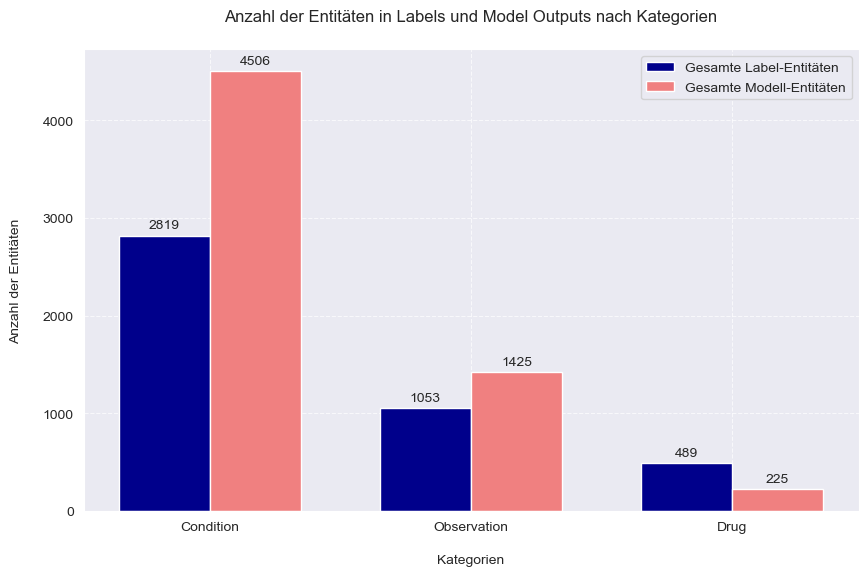

In [16]:
plot_metrics(metrics)